<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Isolated_Forest_Video.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest

In [3]:
# Configuración estética: Fondo oscuro para resaltar en videos
plt.style.use('dark_background')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

Dataset creado con éxito: 330 puntos totales (30 anomalías potenciales).


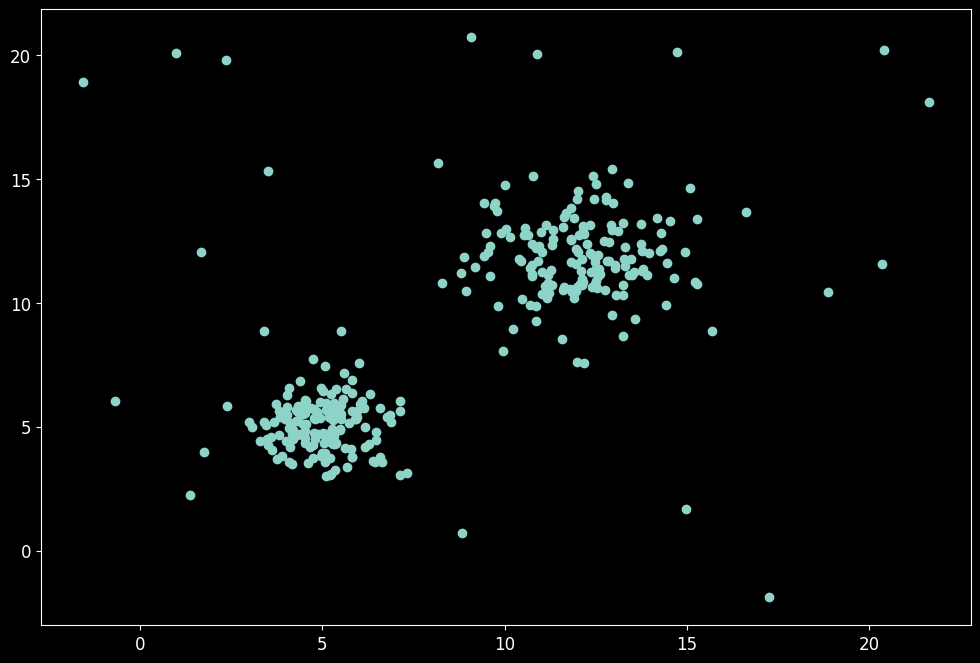

In [9]:
# Generamos dos grupos de datos normales y luego añadimos anomalías dispersas.
np.random.seed(42)

# Datos normales (Inliers) - Dos clusters simulando comportamiento habitual
cluster_1 = np.random.normal(loc=5, scale=1.0, size=(150, 2))
cluster_2 = np.random.normal(loc=12, scale=1.5, size=(150, 2))
datos_normales = np.vstack([cluster_1, cluster_2])

# Datos anómalos (Outliers) - Puntos lejanos y dispersos
anomalias = np.random.uniform(low=-2, high=22, size=(30, 2))

# Combinamos todo en un solo DataFrame
X = np.vstack([datos_normales, anomalias])
df = pd.DataFrame(X, columns=['Característica A', 'Característica B'])


plt.scatter(X[:,0],X[:,1])

print(f"Dataset creado con éxito: {df.shape[0]} puntos totales (30 anomalías potenciales).")

In [10]:
# Ajustamos el modelo. El parámetro 'contamination' define el % estimado de anomalías.
porcentaje_contaminacion = 0.10  # 10% de anomalías estimadas
modelo_if = IsolationForest(contamination=porcentaje_contaminacion, random_state=42)

In [11]:
# Entrenamos y predecimos directamente
# 1 = Dato Normal, -1 = Anomalía
df['Resultado'] = modelo_if.fit_predict(X)
df['Score_Anomalia'] = modelo_if.decision_function(X) # Puntuación de aislamiento

# Separamos para facilitar la graficación
normales_predichos = df[df['Resultado'] == 1]
anomalias_predichas = df[df['Resultado'] == -1]

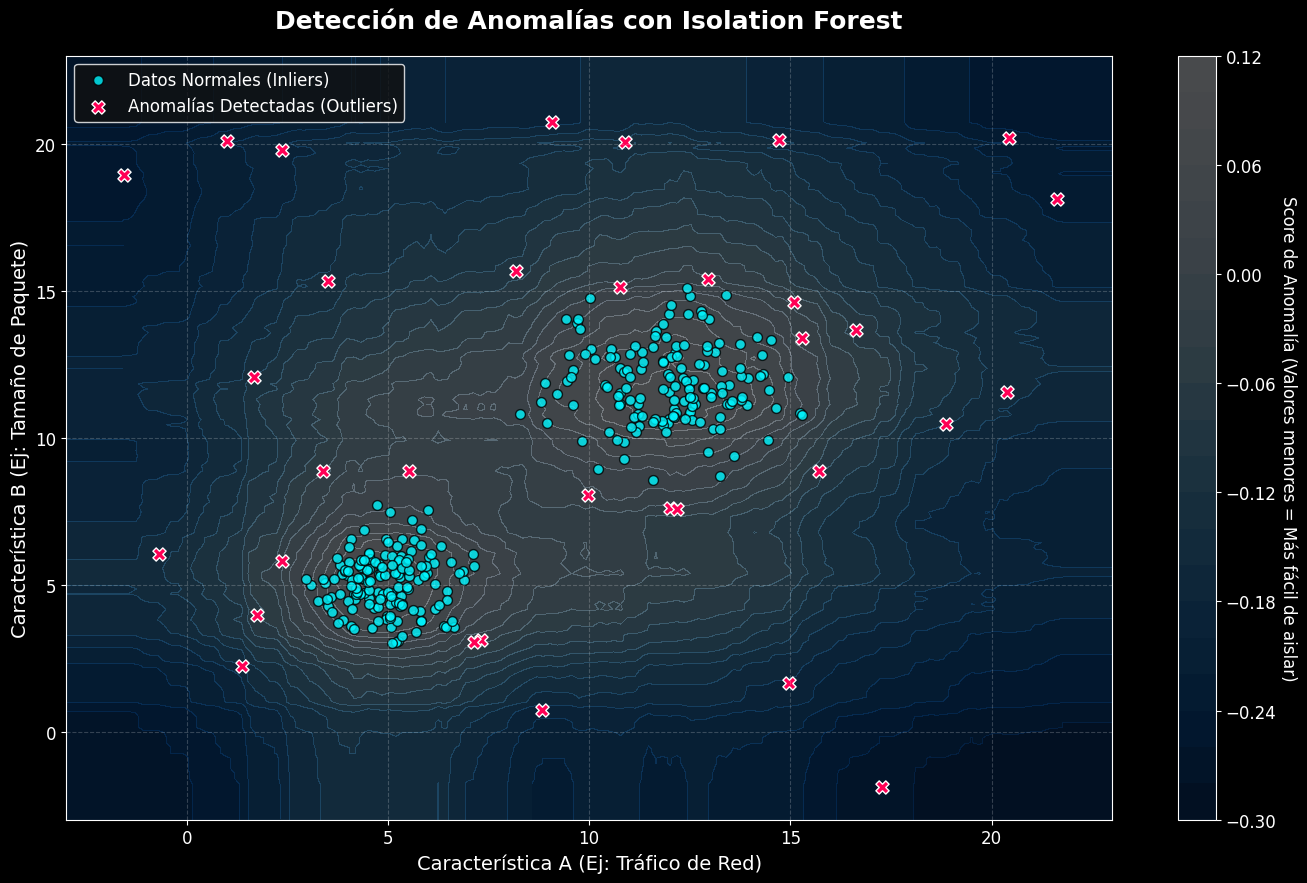

In [12]:
# 4. GRÁFICA PARA EL VIDEO: VISUALIZACIÓN DE RESULTADOS

fig, ax = plt.subplots(figsize=(14, 9))

# Creamos un mapa de calor de fondo basado en el Score de Anomalía para ver las fronteras
xx, yy = np.meshgrid(np.linspace(-3, 23, 150), np.linspace(-3, 23, 150))
Z = modelo_if.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Dibujamos las regiones de decisión (Fondo dinámico)
contorno = ax.contourf(xx, yy, Z, cmap=plt.cm.Blues_r, alpha=0.3, levels=20)
cbar = plt.colorbar(contorno, ax=ax)
cbar.set_label('Score de Anomalía (Valores menores = Más fácil de aislar)', rotation=270, labelpad=15)

# Graficamos los puntos normales (Inliers) en verde neón o azul cian
ax.scatter(normales_predichos['Característica A'], normales_predichos['Característica B'],
           c='#00f6ff', label='Datos Normales (Inliers)', s=50, edgecolors='black', alpha=0.8)

# Graficamos las anomalías (Outliers) en rojo brillante para que impacte en el video
ax.scatter(anomalias_predichas['Característica A'], anomalias_predichas['Característica B'],
           c='#ff0055', label='Anomalías Detectadas (Outliers)', s=90, marker='X', edgecolors='white')

# Detalles visuales finales
ax.set_title('Detección de Anomalías con Isolation Forest', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Característica A (Ej: Tráfico de Red)', fontsize=14)
ax.set_ylabel('Característica B (Ej: Tamaño de Paquete)', fontsize=14)
ax.legend(loc='upper left', fontsize=12, facecolor='#111111', edgecolor='white')
ax.grid(True, linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()